# Activity: Clustering Techniques in Customer Segmentation

#### Overview
This session is devoted to the practical application of clustering techniques in machine learning, utilizing them on the Mall Customer dataset. We aim to explore the subtleties of cluster analysis and how it can unveil hidden patterns within customer data, aiding in effective market segmentation.

#### What We Will Do:
- Dataset Familiarization: Analyze the Mall Customer dataset to understand the features that may influence customer shopping patterns.
- K-means Clustering: Implement K-means clustering, determine the optimal number of clusters with the Elbow Method and Silhouette Analysis, and visualize the segmentation.
- Hierarchical Clustering: Delve into hierarchical clustering using different linkage methods and interpret the clustering results through dendrogram visualizations.
- Comparative Evaluation: Assess the cluster quality using the Silhouette Coefficient and compare the segments derived from both K-means and hierarchical clustering.
- Insights and Business Strategy: Interpret the clusters to gain insights into customer behaviors and discuss the potential business strategies that could be informed by these customer segments.

#### Outcome
By the end of this activity, participants will have gained hands-on experience in clustering analysis, specifically K-means and hierarchical clustering, applied to real-world customer data. This session will enhance our understanding of market segmentation and how to extract actionable insights from complex datasets, equipping us with the knowledge to drive data-informed marketing strategies.

## 1. Import necessary libraries and modules

In [1]:
import os
# Set OMP_NUM_THREADS environment variable to 1
os.environ['OMP_NUM_THREADS'] = '1'

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# For KMeans Clustering
from sklearn.cluster import KMeans

# For silhouette analysis
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer # for silhouette visulaization

# For Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

You may need install `yellowbrick` package, you can do it by uncomment the following cell :

In [ ]:
# !pip install yellowbrick

## 2. Load the data

In [2]:
df = pd.read_csv("..\data\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Exploratory Data Analysis

### Exploring the data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 4. Data Preprocessing

### Handling the Missing value

In [7]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Handling categorical data

Replacing gender with numerical values is essential as KMeans requires numerical input. It allows the algorithm to calculate distances between data points.

In [8]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [3]:
df_modified = pd.get_dummies(df, columns=['Gender'], drop_first = True, dtype = int)
df_modified.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [4]:
# Revoving CustomerID from the training data 
df_modified = df_modified.drop(['CustomerID'], axis = 1)
df_modified.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


## 5. KMeans Clustering

### 1. Determining the optimal number of clusters (k)

#### 1. The Elbow Method

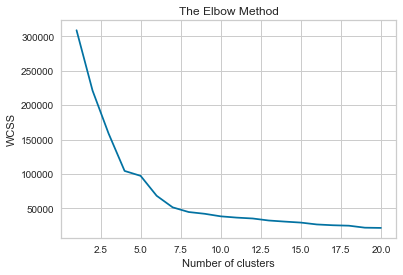

In [6]:
inertia = []  # inertia or Within-Cluster-Sum-of-Squares, lower values are better
for i in range(1, 21):  # Test with number of clusters from 1 to 20
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init = 'auto', random_state=42)
    kmeans.fit(df_modified)
    inertia.append(kmeans.inertia_)  # inertia_ is the WCSS for the current model

plt.plot(range(1, 21), inertia)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#### 2. Silhouette analysis

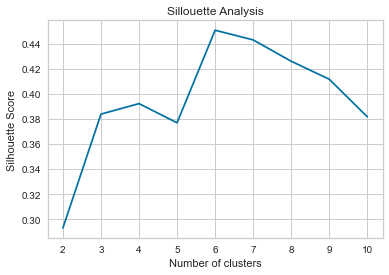

In [14]:
sil = []
kmax = 10

# dissimilarity would not be defined for a single cluster, thus, minimum number of clusters should be 2
for k in range(2, kmax+1):
  kmeans = KMeans(n_clusters = k, n_init = 'auto', random_state = 0).fit(df_modified)
  labels = kmeans.labels_
  sil.append(silhouette_score(df_modified, labels, metric = 'euclidean'))

plt.plot(range(2, 11), sil)
plt.title('Sillouette Analysis')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

- **Sillouette plot of a model with 4 clusters**

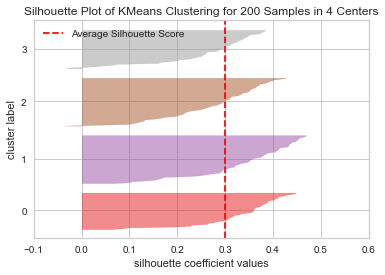

# of clusters: 4
Silhouette score 0.29895590180505627


In [22]:
silh = SilhouetteVisualizer(KMeans(4, random_state = 0, n_init = 'auto'))
silh.fit(df_scaled)
silh.poof()
print("# of clusters:", silh.n_clusters_)
print("Silhouette score", silh.silhouette_score_)

- **Sillouette plot of a model with 5 cluster**

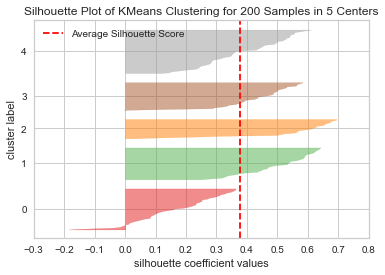

# of clusters: 5
Silhouette score 0.37688936241822546


In [17]:
silh = SilhouetteVisualizer(KMeans(5, random_state = 0, n_init = 'auto'))
silh.fit(df_modified)
silh.poof()
print("# of clusters:", silh.n_clusters_)
print("Silhouette score", silh.silhouette_score_)

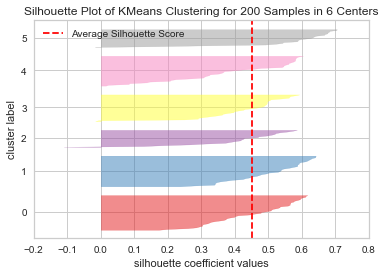

# of clusters: 6
Silhouette score 0.4506609653808789


In [18]:
silh = SilhouetteVisualizer(KMeans(6, random_state = 0, n_init = 'auto'))
silh.fit(df_modified)
silh.poof()
print("# of clusters:", silh.n_clusters_)
print("Silhouette score", silh.silhouette_score_)

### 2. Apply KMeans & Visualize the clusters 

#### Kmeans with 5 clusters

Apply KMeans with the number of clusters where the WCSS starts to decrease more slowly, which is often considered the "elbow" - in this case, 5 clusters.

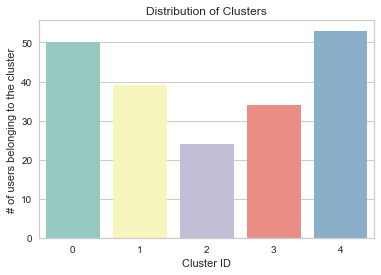

In [59]:
n_clusters = 5

# defining the kmeans function with initialization as k-means++
kmeans = KMeans(n_clusters = n_clusters, n_init = 'auto', random_state = 0)

# fitting the k means algorithm and Make clusters
kmeans_clusters = kmeans.fit_predict(df_modified)

# Visualize the partiting of each cluster
sns.countplot(x = kmeans_clusters, hue = kmeans_clusters, palette = 'Set3', legend = False)
plt.title('Distribution of Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('# of users belonging to the cluster')
plt.show()

#### Visualize the clusters

Visualize the resulting clusters and their centers to understand the segmentation of data.

In [27]:
clusters_ = pd.DataFrame(kmeans_clusters).rename(columns = {0: "clusters"}) # convert to df
# concat the predicted clusters to original data set
df_clusters = pd.concat([df, clusters_], axis = 1) # concat with original data set
df_clusters.head()
# cluster_id is the last column 

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,0


- Visualization with spending score and annual income

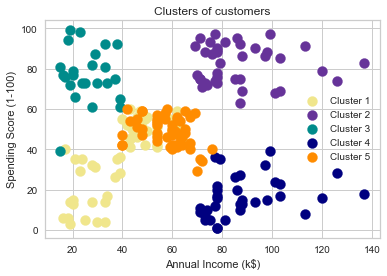

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clusters[df_clusters['clusters'] == 0][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 0][['Spending Score (1-100)']], s = 100, c = 'khaki', label = 'Cluster 1')
plt.scatter(df_clusters[df_clusters['clusters'] == 1][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 1][['Spending Score (1-100)']], s = 100, c = 'rebeccapurple', label = 'Cluster 2')
plt.scatter(df_clusters[df_clusters['clusters'] == 2][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 2][['Spending Score (1-100)']], s = 100, c = 'darkcyan', label = 'Cluster 3')
plt.scatter(df_clusters[df_clusters['clusters'] == 3][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 3][['Spending Score (1-100)']], s = 100, c = 'navy', label = 'Cluster 4')
plt.scatter(df_clusters[df_clusters['clusters'] == 4][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 4][['Spending Score (1-100)']], s = 100, c = 'darkorange', label = 'Cluster 5')


plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

- Visualization with spending score and age 

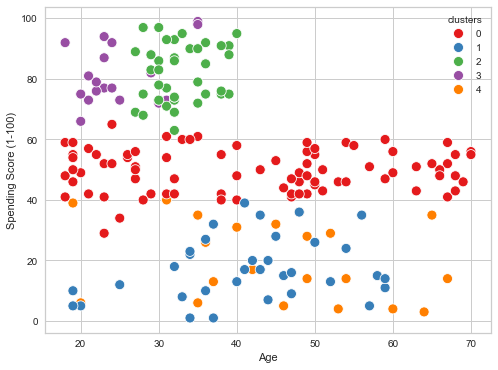

In [60]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='clusters', data=df_clusters, palette='Set1', s = 100)
plt.show()

- Visualization gender across Clusters

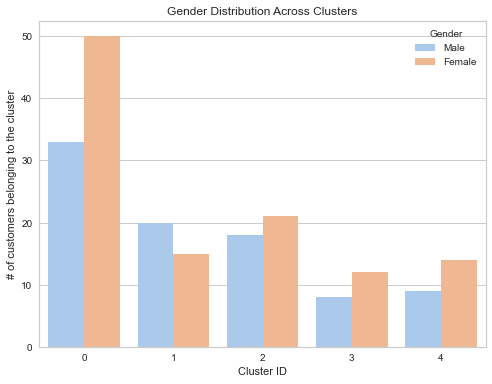

In [61]:
plt.figure(figsize=(8, 6))
sns.countplot(data = df_clusters, hue = 'Gender', x = 'clusters', palette='pastel')
plt.title('Gender Distribution Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('# of customers belonging to the cluster')
plt.show()

### Kmeans with 4 clusters

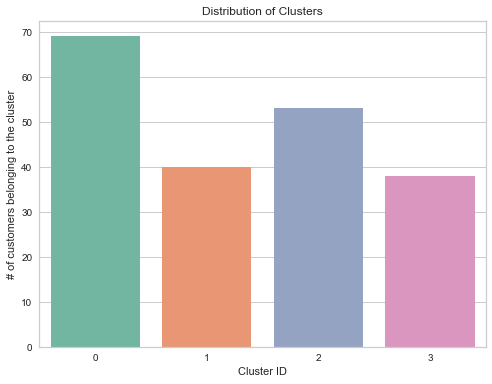

In [63]:
n_clusters = 4

# defining the kmeans function with initialization as k-means++
kmeans = KMeans(n_clusters = n_clusters, n_init = 'auto')

# fitting the k means algorithm and Make clusters
kmeans_clusters = kmeans.fit_predict(df_modified)

# Visualize the partiting of each cluster
plt.figure(figsize=(8, 6))
sns.countplot(x = kmeans_clusters, hue = kmeans_clusters, palette = 'Set2', legend = False)
plt.title('Distribution of Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('# of customers belonging to the cluster')
plt.show()

In [65]:
clusters_ = pd.DataFrame(kmeans_clusters).rename(columns = {0: "clusters"}) # convert to df
# concat the predicted clusters to original data set
df_clusters = pd.concat([df, clusters_], axis = 1) # concat with original data set
df_clusters.head()
# cluster_id is the last column 

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,0
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


- Visualization with spending score and annual income

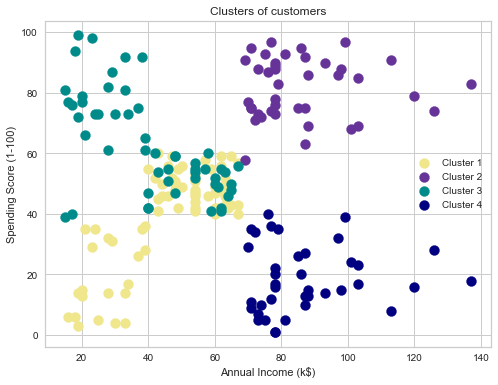

In [66]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clusters[df_clusters['clusters'] == 0][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 0][['Spending Score (1-100)']], s = 100, c = 'khaki', label = 'Cluster 1')
plt.scatter(df_clusters[df_clusters['clusters'] == 1][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 1][['Spending Score (1-100)']], s = 100, c = 'rebeccapurple', label = 'Cluster 2')
plt.scatter(df_clusters[df_clusters['clusters'] == 2][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 2][['Spending Score (1-100)']], s = 100, c = 'darkcyan', label = 'Cluster 3')
plt.scatter(df_clusters[df_clusters['clusters'] == 3][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 3][['Spending Score (1-100)']], s = 100, c = 'navy', label = 'Cluster 4')



plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

- Visualization with spending score and age

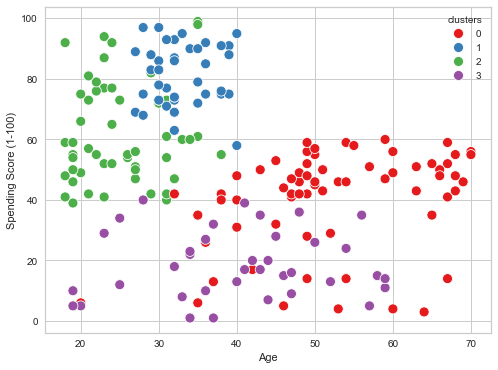

In [67]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='clusters', data=df_clusters, palette='Set1', s = 100)
plt.show()

- Visualization gender across Clusters

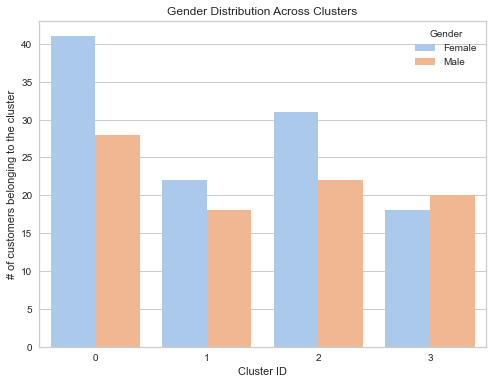

In [69]:
# Visualize the partiting of each cluster
plt.figure(figsize=(8, 6))
sns.countplot(data = df_clusters, hue = 'Gender', x = 'clusters',palette='pastel')
plt.title('Gender Distribution Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('# of customers belonging to the cluster')
plt.show()

### Kmeans with 6 clusters

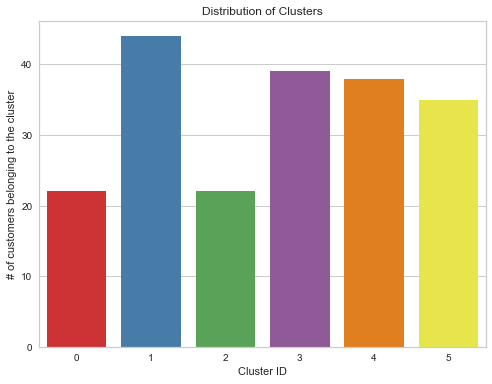

In [70]:
n_clusters = 6

# defining the kmeans function with initialization as k-means++
kmeans = KMeans(n_clusters = n_clusters, n_init = 'auto')

# fitting the k means algorithm and Make clusters
kmeans_clusters = kmeans.fit_predict(df_modified)

# Visualize the partiting of each cluster
plt.figure(figsize=(8, 6))
sns.countplot(x = kmeans_clusters, hue = kmeans_clusters, palette = 'Set1', legend = False)
plt.title('Distribution of Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('# of customers belonging to the cluster')
plt.show()

In [71]:
clusters_ = pd.DataFrame(kmeans_clusters).rename(columns = {0: "clusters"}) # convert to df
# concat the predicted clusters to original data set
df_clusters = pd.concat([df, clusters_], axis = 1) # concat with original data set
df_clusters.head()
# cluster_id is the last column 

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,2
1,2,Male,21,15,81,0
2,3,Female,20,16,6,2
3,4,Female,23,16,77,0
4,5,Female,31,17,40,2


- Visualization with spending score and annual income

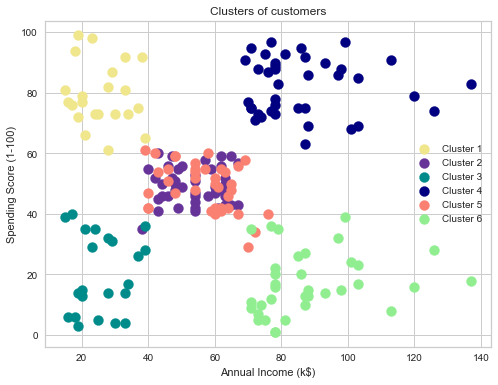

In [72]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clusters[df_clusters['clusters'] == 0][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 0][['Spending Score (1-100)']], s = 100, c = 'khaki', label = 'Cluster 1')
plt.scatter(df_clusters[df_clusters['clusters'] == 1][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 1][['Spending Score (1-100)']], s = 100, c = 'rebeccapurple', label = 'Cluster 2')
plt.scatter(df_clusters[df_clusters['clusters'] == 2][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 2][['Spending Score (1-100)']], s = 100, c = 'darkcyan', label = 'Cluster 3')
plt.scatter(df_clusters[df_clusters['clusters'] == 3][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 3][['Spending Score (1-100)']], s = 100, c = 'navy', label = 'Cluster 4')
plt.scatter(df_clusters[df_clusters['clusters'] == 4][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 4][['Spending Score (1-100)']], s = 100, c = 'salmon', label = 'Cluster 5')
plt.scatter(df_clusters[df_clusters['clusters'] == 5][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 5][['Spending Score (1-100)']], s = 100, c = 'lightgreen', label = 'Cluster 6')



plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

- Visualization with spending score and age

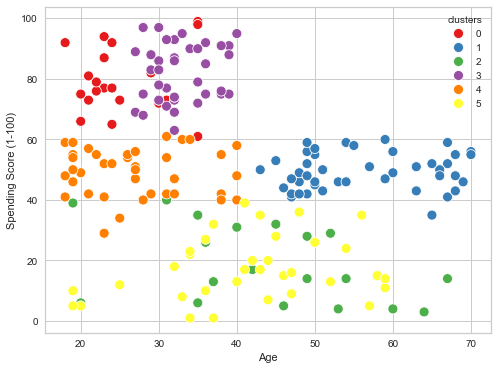

In [73]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='clusters', data=df_clusters, palette='Set1', s = 100)
plt.show()

- Visualization gender across Clusters

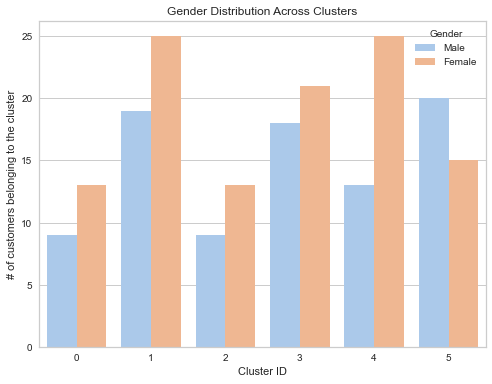

In [74]:
plt.figure(figsize=(8, 6))
# Visualize the partiting of each cluster
sns.countplot(data = df_clusters, hue = 'Gender', x = 'clusters',palette='pastel')
plt.title('Gender Distribution Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('# of customers belonging to the cluster')
plt.show()

### Discussion

Discussion Questions:

1. **Understanding Clusters:** Describe the characteristics of each cluster. What does each cluster represent in terms of customer behavior?
2. **Impact of Gender:** How would including gender in the clustering process potentially impact the clusters?
3. **Business Implications:** How might the mall use this clustering information for marketing or customer engagement strategies?

## 6. Hierarchical Clustering

### 1. Analyzing Hierarchical Relationships with Dendrograms

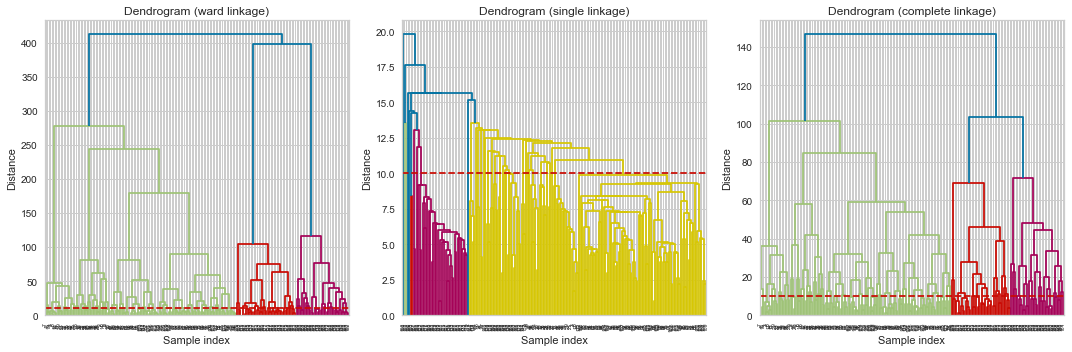

In [47]:
# Hierarchical clustering using different linkage methods
linkage_methods = ['ward', 'single', 'complete']

# Create a figure for subplots
plt.figure(figsize=(15, 5))

# Perform hierarchical clustering and plot dendrograms for each linkage method
for i, method in enumerate(linkage_methods):
    # Compute the linkage matrix
    Z = linkage(df_modified, method=method)
    
    # Create a subplot for the dendrogram
    plt.subplot(1, len(linkage_methods), i+1)
    
    # Plot the dendrogram
    dendrogram(Z)
    plt.title(f'Dendrogram ({method} linkage)')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')
    
    # Annotate the height at which clusters will be distinguished for this method
    plt.axhline(y=10, color='r', linestyle='--')

plt.tight_layout()
plt.show()

### 2. Implementing Agglomerative Clustering 

In [45]:
agglo = AgglomerativeClustering(n_clusters=5)
agglo_clusters = agglo.fit_predict(df_modified)
print('Sillouette score:', silhouette_score(df_modified, agglo_clusters, metric = 'euclidean'))

Sillouette score: 0.43997527212476695


In [46]:
clusters_ = pd.DataFrame(agglo_clusters).rename(columns = {0: "clusters"}) # convert to df
# concat the predicted clusters to original data set
df_clusters = pd.concat([df, clusters_], axis = 1) # concat with original data set
df_clusters.head()
# cluster_id is the last column 

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


### 3.Clusters Visulization

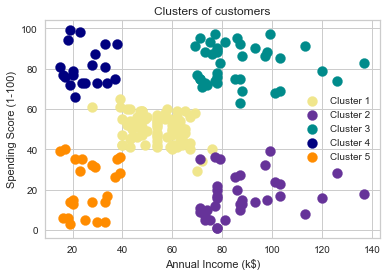

In [47]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clusters[df_clusters['clusters'] == 0][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 0][['Spending Score (1-100)']], s = 100, c = 'khaki', label = 'Cluster 1')
plt.scatter(df_clusters[df_clusters['clusters'] == 1][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 1][['Spending Score (1-100)']], s = 100, c = 'rebeccapurple', label = 'Cluster 2')
plt.scatter(df_clusters[df_clusters['clusters'] == 2][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 2][['Spending Score (1-100)']], s = 100, c = 'darkcyan', label = 'Cluster 3')
plt.scatter(df_clusters[df_clusters['clusters'] == 3][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 3][['Spending Score (1-100)']], s = 100, c = 'navy', label = 'Cluster 4')
plt.scatter(df_clusters[df_clusters['clusters'] == 4][['Annual Income (k$)']], df_clusters[df_clusters['clusters'] == 4][['Spending Score (1-100)']], s = 100, c = 'darkorange', label = 'Cluster 5')


plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()